# 01 — Control-Flow Perspective

This notebook analyses the control-flow perspective of the student-journey case study. We compare the journeys of students who **graduate on time** and those who **graduate late**. Both come ready from `00_preprocess.ipynb`.

The comparison uses the **block-structured architecture** — summation within a block,
concatenation across the `c` context blocks, and scattered prediction of the next block's
members — via the **compass method**: one compass model on both cohorts combined, then one
frozen-output model per cohort.

The notebook runs in three steps:

1. **Train** — load the logs, fit the balanced compass on both cohorts combined, then one
   frozen-output model per cohort; each model is cached under `results/artefacts`.
2. **Summary** — one table of the per-activity cosine, read against how often the activity
   occurs in each cohort, plus the same numbers as a CSV.
3. **Drill-down** — for a single course in the last context position, the next-block
   distribution it alone predicts, per cohort.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import log_comparison_block as lcb  # the shared block-structured architecture

SEED = 42
lcb.set_seed(SEED)

# --- input
BASE_DIR = Path(lcb.__file__).resolve().parent
LOG_DIR = BASE_DIR / "data" / "preprocessed"
NAMES = ("on-time", "late")
LOG_PATHS = {n: LOG_DIR / f"students_{n}.csv" for n in NAMES}

# --- architecture and training schedule
C = 2  # context window c, in blocks (= semesters)
EMBEDDING_DIM = 32
UNIT_NORM = True  # keep the embeddings on the unit sphere: every embedding is
# L2-normalised before it enters the context vector, and the read-out is normalised too,
# so a course (or value) is described by its direction alone -- what the cosine reads
LEARNING_RATE_COMPASS, EPOCHS_COMPASS = 1e-2, 1000
LEARNING_RATE, EPOCHS = 1e-2, 1000
DEVICE = "cpu"

# --- outputs
RESULTS_DIR = BASE_DIR / "results"  # the result tables
ARTEFACTS_DIR = RESULTS_DIR / "artefacts"  # the trained models
ARTEFACTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATHS = {
    "compass": ARTEFACTS_DIR / "01_control-flow_compass.pt",
    **{n: ARTEFACTS_DIR / f"01_control-flow_{n}.pt" for n in NAMES},
}
SIM_PATH = RESULTS_DIR / "01_control-flow_similarity-frequency.csv"

# True retrains all three models, False reuses the cached ones
RECOMPUTE_EMBEDDINGS = True

for n, p in LOG_PATHS.items():
    assert p.exists(), f"log {n!r} not found: {p} — run 00_preprocess.ipynb first"

# reusing the cache needs all three files; without them there is nothing to load
missing = [n for n, p in MODEL_PATHS.items() if not p.exists()]
if not RECOMPUTE_EMBEDDINGS and missing:
    print(
        "missing:",
        *[f"{n} -> {MODEL_PATHS[n].name}" for n in missing],
        "set RECOMPUTE_EMBEDDINGS = True to train them",
        sep="\n        ",
    )

## 2. Train the models (compass method)

Both cohorts come ready from `00_preprocess.ipynb`.

One **compass** model, fitted on both cohorts combined, fixes the shared output matrix
$\mathbf{E}_{\mathrm{out}}$; each cohort is then retrained from the compass with that output
**frozen**, so only its input embeddings move — against one and the same output space.

`balance_compass=True` rescales the smaller cohort's case counts so both logs weigh equally in
the compass loss. The three models are cached individually. If `RECOMPUTE_EMBEDDINGS = False`,
they are loaded instead of retrained.

In [13]:
logs = {n: pd.read_csv(p) for n, p in LOG_PATHS.items()}

--- BLOCK_STRUCTURED COMPASS on the combined log, case counts scaled by {'on-time': 4.44, 'late': 1.0} ---
Using device: cpu — 1000 epochs, lr=1.0e-02, unit norm


compass:   0%|          | 0/1000 [00:00<?, ?it/s]

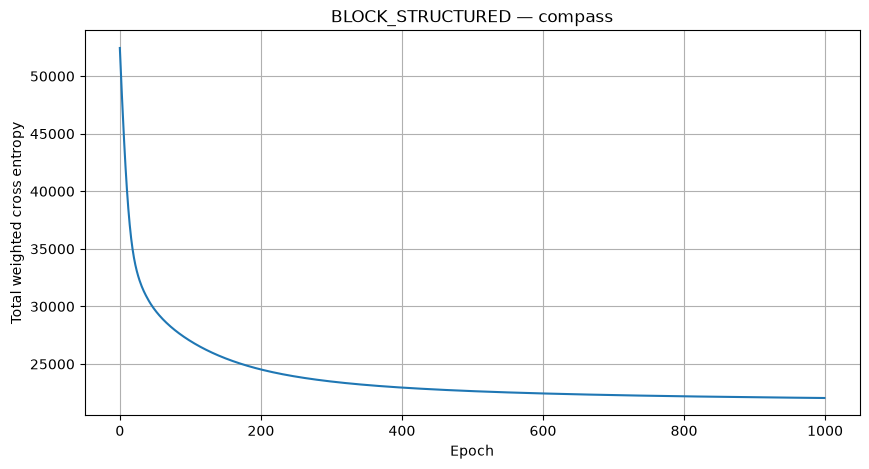

--- BLOCK_STRUCTURED RETRAINING on log on-time ---
Using device: cpu — 1000 epochs, lr=1.0e-02, unit norm, frozen output


on-time:   0%|          | 0/1000 [00:00<?, ?it/s]

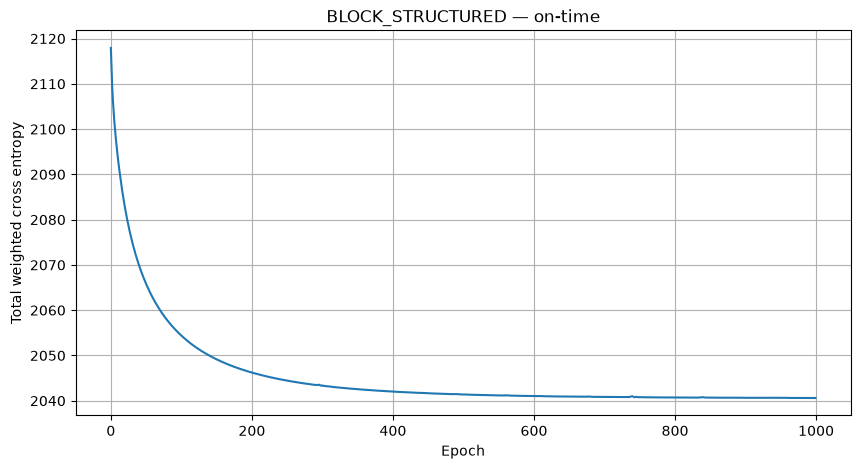

--- BLOCK_STRUCTURED RETRAINING on log late ---
Using device: cpu — 1000 epochs, lr=1.0e-02, unit norm, frozen output


late:   0%|          | 0/1000 [00:00<?, ?it/s]

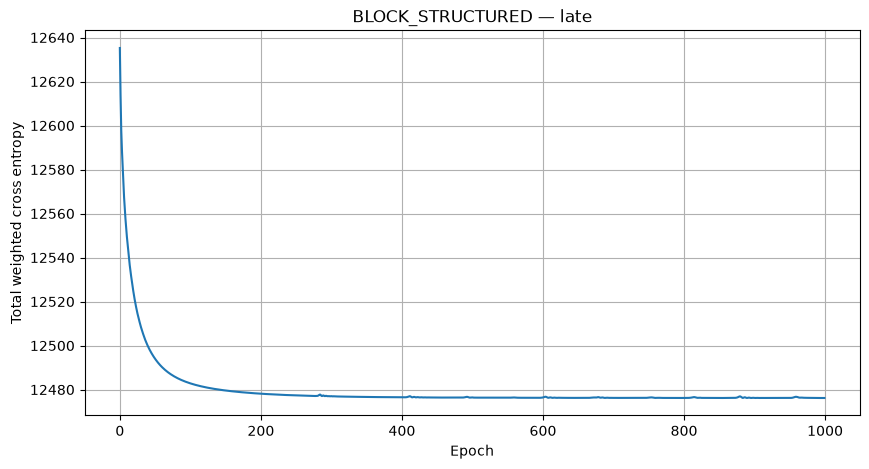

In [14]:
if RECOMPUTE_EMBEDDINGS:
    model_i, model_j, compass = lcb.compare_block_event_logs(
        logs[NAMES[0]],
        logs[NAMES[1]],
        names=NAMES,
        c=C,
        embedding_dim=EMBEDDING_DIM,
        compass_learning_rate=LEARNING_RATE_COMPASS,
        compass_epochs=EPOCHS_COMPASS,
        log_learning_rate=LEARNING_RATE,
        log_epochs=EPOCHS,
        unit_norm=UNIT_NORM,
        balance_compass=True,
        device=DEVICE,
        verbose=True,
    )
    models = {"compass": compass, NAMES[0]: model_i, NAMES[1]: model_j}
    for name, model in models.items():
        lcb.save_model(model, MODEL_PATHS[name])
else:
    models = {
        name: lcb.load_model(path, device=DEVICE) for name, path in MODEL_PATHS.items()
    }

## 3. Summary

Cosine similarity of each shared activity's embedding across the two logs: **high** = the
activity sits in the same behavioural context in both journeys (semantically stable), **low** =
the surrounding behaviour differs (semantically shifted). Read against how often the activity
occurs in each cohort. The similarity is colour-coded over the full cosine range, red (`-1`,
the activity sits in different behaviour in the two cohorts) through yellow (`0`) to green
(`+1`, the same behaviour).

The same numbers go to `01_control-flow_similarity-frequency.csv`.

In [15]:
sim = lcb.activity_similarity(models[NAMES[0]], models[NAMES[1]])
# how often each activity occurs in a cohort — the weight it carries into training
freq = {n: df["concept:name"].value_counts() for n, df in logs.items()}

result = pd.DataFrame(
    {
        "cosine_similarity": sim,
        **{f"freq {n}": freq[n].reindex(sim.index) for n in NAMES},
    }
).sort_values("cosine_similarity", ascending=True)
result["mean_freq"] = result[[f"freq {n}" for n in NAMES]].mean(axis=1)
result.to_csv(SIM_PATH, index_label="activity")

In [16]:
# the most stable (top), the middle of the ranking and the most shifted (bottom), with a
# gap row marking how many activities are left out in between (None = show everything)
HEAD_N, MID_N, TAIL_N = 5, 5, 5

full = (
    result.drop(columns="mean_freq")
    .rename_axis("activity")
    .rename(columns={"cosine_similarity": "sim"})
    .reset_index()
)
n_total = len(full)


def gap(n_hidden):
    """A single all-NaN row labelled with how many activities it stands for."""
    return pd.DataFrame([{"activity": f"... {n_hidden} more ..."}]).reindex(
        columns=full.columns
    )


if None in (HEAD_N, MID_N, TAIL_N) or n_total <= HEAD_N + MID_N + TAIL_N:
    shown = full
else:
    mid_start = (n_total - MID_N) // 2
    shown = pd.concat(
        [
            full.head(HEAD_N),
            gap(mid_start - HEAD_N),
            full.iloc[mid_start : mid_start + MID_N],
            gap(n_total - TAIL_N - (mid_start + MID_N)),
            full.tail(TAIL_N),
        ],
        ignore_index=True,
    )

display(
    shown.style.format(
        {"sim": "{:+.3f}", **{f"freq {n}": "{:,.0f}" for n in NAMES}},
        na_rep="",  # the gap rows, which stand for the activities left out
    )
    .background_gradient(subset=["sim"], cmap="RdYlGn", vmin=-1, vmax=1)
    # the gradient paints a missing cosine solid black -- keep the gap rows plain
    .map(
        lambda v: "background-color: transparent; color: inherit" if pd.isna(v) else "",
        subset=["sim"],
    )
    .map(
        lambda v: "color: #d62728" if v == 0 else "",
        subset=[f"freq {n}" for n in NAMES],
    )
    .set_properties(subset=["activity"], **{"text-align": "left"})
    .set_caption("shared activities")
    .hide(axis="index")
)

activity,sim,freq on-time,freq late
Intro Informatics (pass),+0.006,1,1
Op Sys (fail),+0.048,5,41
Inf Adm & Manag (fail),+0.084,1,2
Alg 2 (fail),+0.115,2,14
Cal 1 (fail),+0.138,1,49
... 23 more ...,,,
Fund Econ (fail),+0.588,2,34
Progr Parad (fail),+0.602,5,69
Progr Methd (pass),+0.603,28,147
Std Methods (pass),+0.621,27,153


## 4. Drill-down: what one course alone predicts

The context vector concatenates the `c` preceding blocks, so the output matrix scores each
position with its own block of rows: a course exerts a *different* forward pull depending on
how many semesters back it sits. Putting one course alone into one context block — everything
else held at zero — and pushing that context through the output matrix and the softmax gives
the next-block distribution **attributable to that course**.

`E_out` carries a **bias** as well as the matrix — one learned offset per target, added to every
logit whatever the context — so it encodes how often a target occurs, not what *this* token
pulls towards. In a real context `h` is the sum of a whole semester's embeddings and the bias is
a modest correction; in this drill-down `h` holds a single unit vector, and the bias outweighs
it. `DRILL_INCLUDE_BIAS = False` therefore scores the context with the matrix alone, which is
the token's own pull; set it to `True` to read the model's actual predictive distribution.

The chart shows the most recent context position only (`t−1`, the semester immediately before
the predicted block; set `DRILL_POSITION` to look further back), one bar colour per cohort. It
keeps the `DRILL_TOP_K` tokens the two cohorts **disagree on most**: where they part, the same
course pulls the journey in different directions.

In [19]:
DRILL_COURSE = "Op Sys (fail)"  # any token of the shared vocabulary
DRILL_TOP_K = 10  # next-block tokens shown
DRILL_POSITION = -1  # which context block: -1 = t-1 (most recent)
DRILL_INCLUDE_BIAS = False  # score with E_out's bias too? see the note above

DRILL_COLOR = {"on-time": "#0098A1", "late": "#E8833A"}

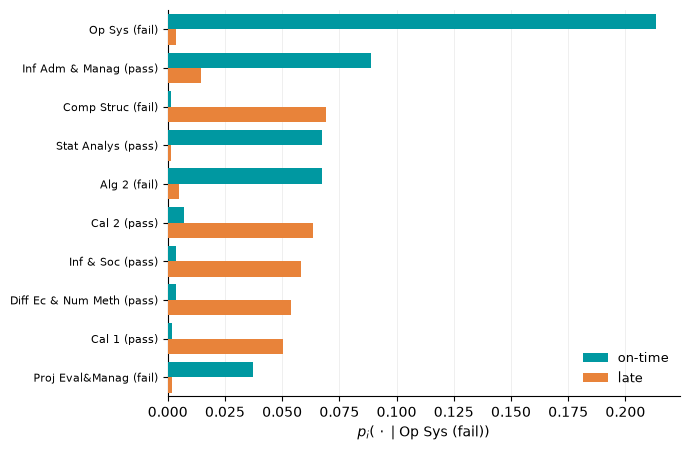

In [ ]:
def course_next_distribution(model, course, position=-1, include_bias=True):
    """The next-block distribution attributable to ``course`` sitting ALONE in
    context block ``position`` (-1 = t-1, the most recent), every other context
    block held at the zero vector.

    Returns a Series over the candidate targets Act(L) u {#END#} — the columns of
    E_out, indexed by ``word_to_ix[token] - lcb.TARGET_OFFSET``.

    :param include_bias: score with E_out's bias as well as its matrix. ``False``
        drops the bias, leaving the token's own pull (see the note above).
    """
    c, d = model.context_window, model.embeddings.embedding_dim
    device = model.output.weight.device
    h = torch.zeros(1, c * d, device=device)
    block = range(c)[position]  # -1 -> the last context block
    with torch.no_grad():
        emb = model.embeddings.weight[model.word_to_ix[course]]
        if model.unit_norm:
            # the forward pass normalises before summing, so h must be built the same way
            emb = torch.nn.functional.normalize(emb, p=2, dim=0)
        h[0, block * d : (block + 1) * d] = emb
        # E_out's bias is one offset per target, added whatever the context, so it
        # says how often a target occurs rather than what THIS token pulls towards.
        # With a single embedding in h it outweighs the token, so the read-out drops
        # it by default and scores the context with the matrix alone.
        logits = model.output(h) if include_bias else h @ model.output.weight.T
        p = torch.softmax(logits, dim=1)[0].cpu()
    targets = [t for t in model.word_to_ix if t != lcb.START_TOKEN]
    return pd.Series(
        {t: float(p[model.word_to_ix[t] - lcb.TARGET_OFFSET]) for t in targets}
    )


dmap = {
    n: course_next_distribution(
        models[n],
        DRILL_COURSE,
        position=DRILL_POSITION,
        include_bias=DRILL_INCLUDE_BIAS,
    )
    for n in NAMES
}

p = pd.DataFrame(dmap)
p["difference"] = (p[NAMES[0]] - p[NAMES[1]]).abs()

# the tokens the two cohorts disagree on most, drawn by size
tokens = list(
    p.loc[p["difference"].nlargest(DRILL_TOP_K).index, list(NAMES)]
    .max(axis=1)
    .sort_values(ascending=False)
    .index
)

y = np.arange(len(tokens))
bh = 0.8 / len(NAMES)

fig, ax = plt.subplots(figsize=(7.0, max(3.0, 0.46 * len(tokens))))
ax.set_axisbelow(True)
ax.xaxis.grid(True, linewidth=0.4, alpha=0.35)
for ei, n in enumerate(NAMES):
    n_events = int(freq[n].get(DRILL_COURSE, 0))
    ax.barh(
        y + (ei - (len(NAMES) - 1) / 2) * bh,
        [dmap[n][t] for t in tokens],
        height=bh,
        color=DRILL_COLOR[n],
        zorder=3,
        label=f"{n}",
    )

ax.set_yticks(y)
ax.set_yticklabels(["(end)" if t == lcb.END_TOKEN else t for t in tokens], fontsize=8)
ax.set_ylim(len(tokens) - 0.5, -0.5)  # the strongest pull at the top
# only the token is escaped -- escaping the whole label would eat the subscript of p_i
drill_label = DRILL_COURSE.replace("_", r"\_").replace(" ", r"\ ")
ax.set_xlabel(rf"$p_i(\,\cdot \mid \mathrm{{{drill_label}}})$")
ax.legend(frameon=False, fontsize=9, loc="lower right")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()